In [91]:
import pandas as pd
import numpy as np
df= pd.read_csv('pima diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [92]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [93]:
print("NULL Count:")
print(df.isnull().sum())

NULL Count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



The following features cant be 0<br>
Glucose<br>
BloodPressure<br>
SkinThickness<br>
Insulin<br>
BMI<br>
we can replace them with null to make the data better in visualization 


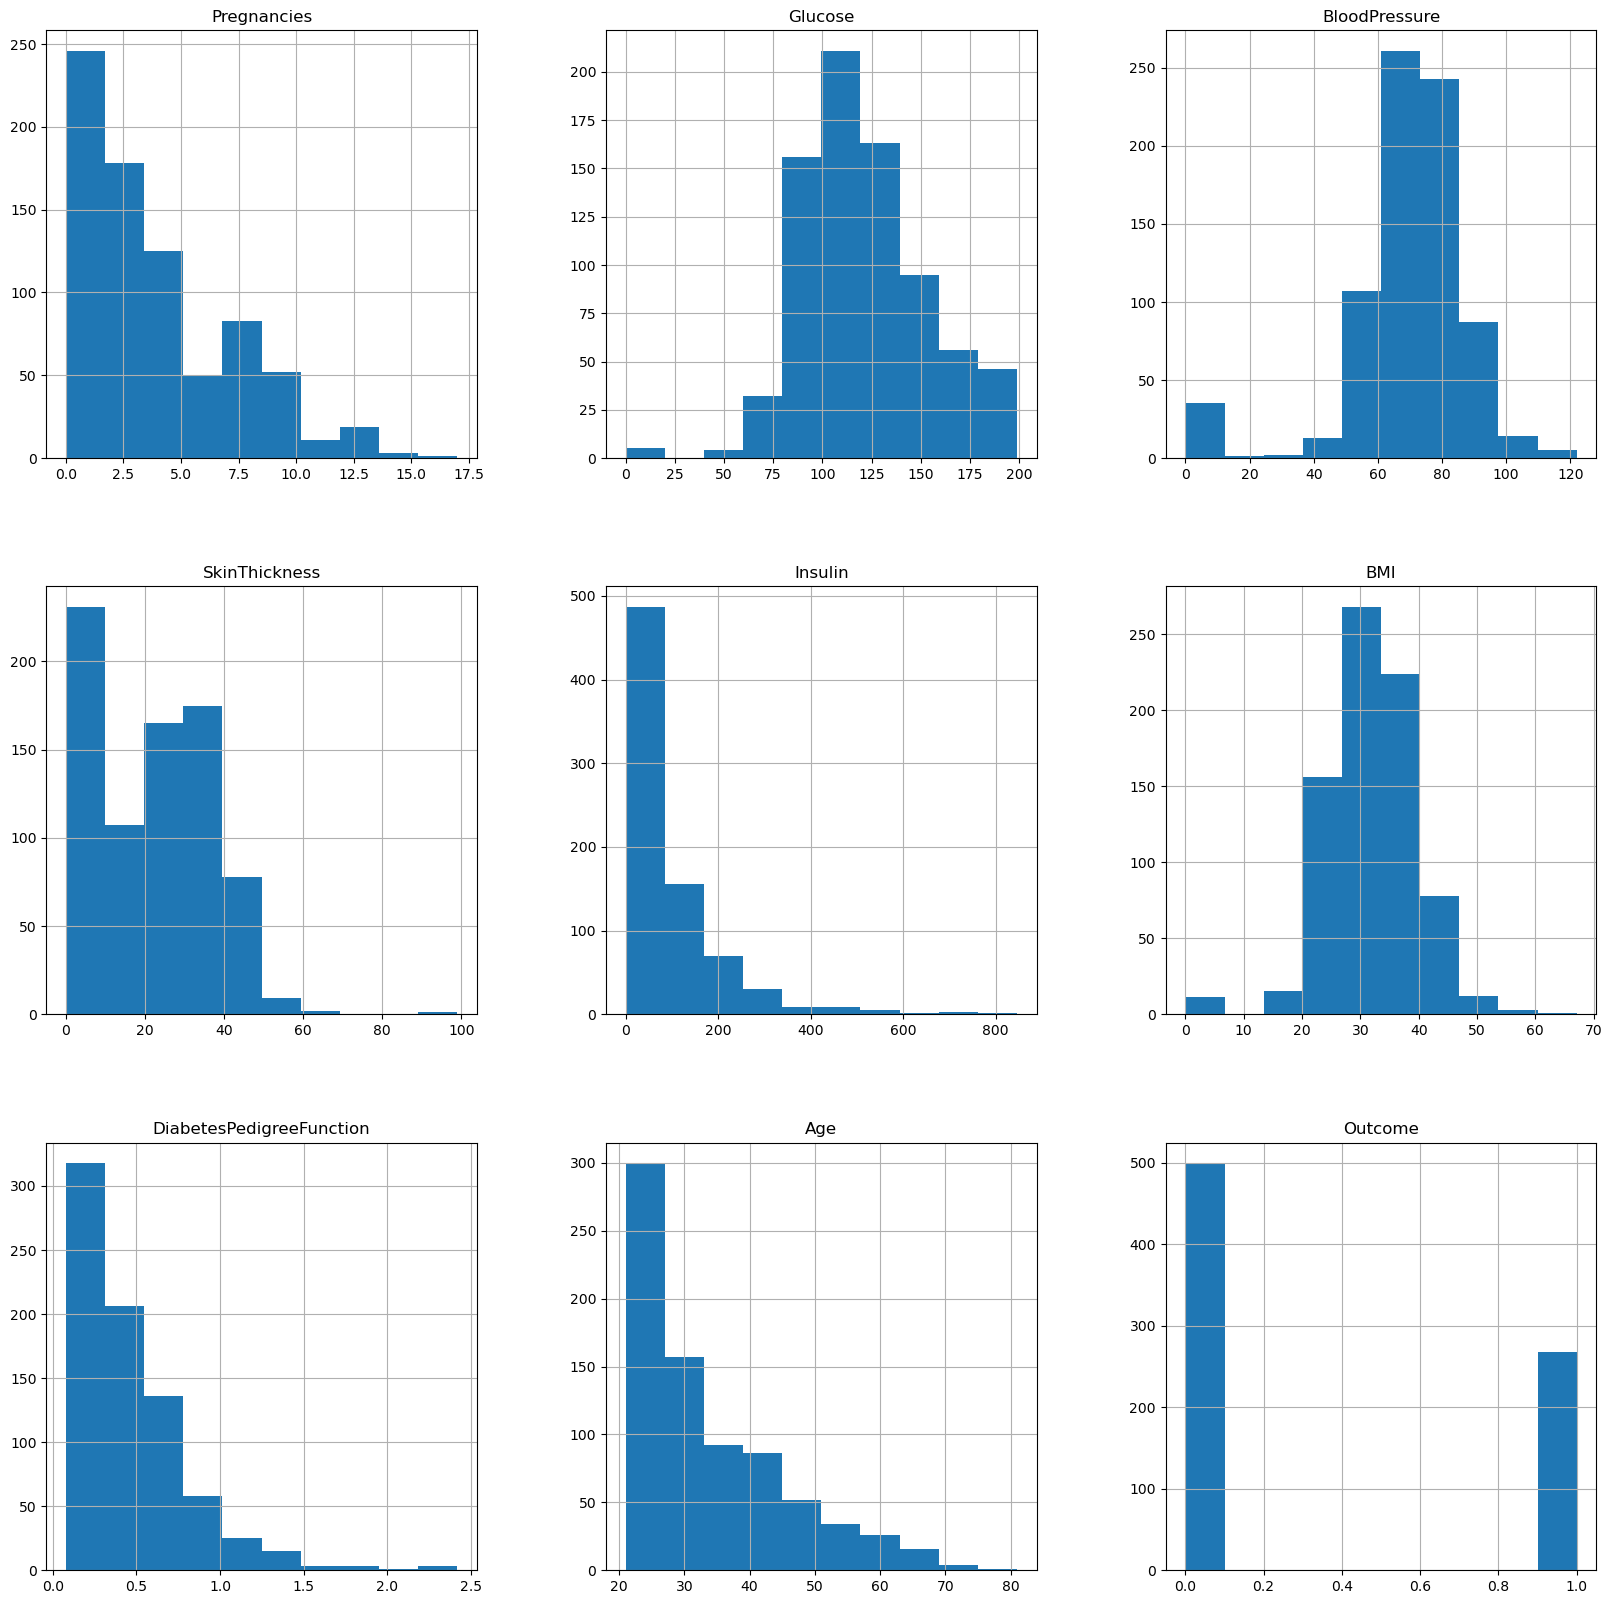

In [94]:

data_hist= df.hist(figsize = (20,20))


In [95]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Training set class distribution:")
print(y_train.value_counts())
print("Testing set class distribution:")
print(y_test.value_counts())

Training set size: 614
Testing set size: 154
Training set class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64
Testing set class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [96]:
complete_data = X.copy(deep=True)
complete_data[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = complete_data[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)


In [97]:
print("NULL Count:")
print(complete_data.isnull().sum())

NULL Count:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


we have a large amount of null data

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>, <Axes: >]], dtype=object)

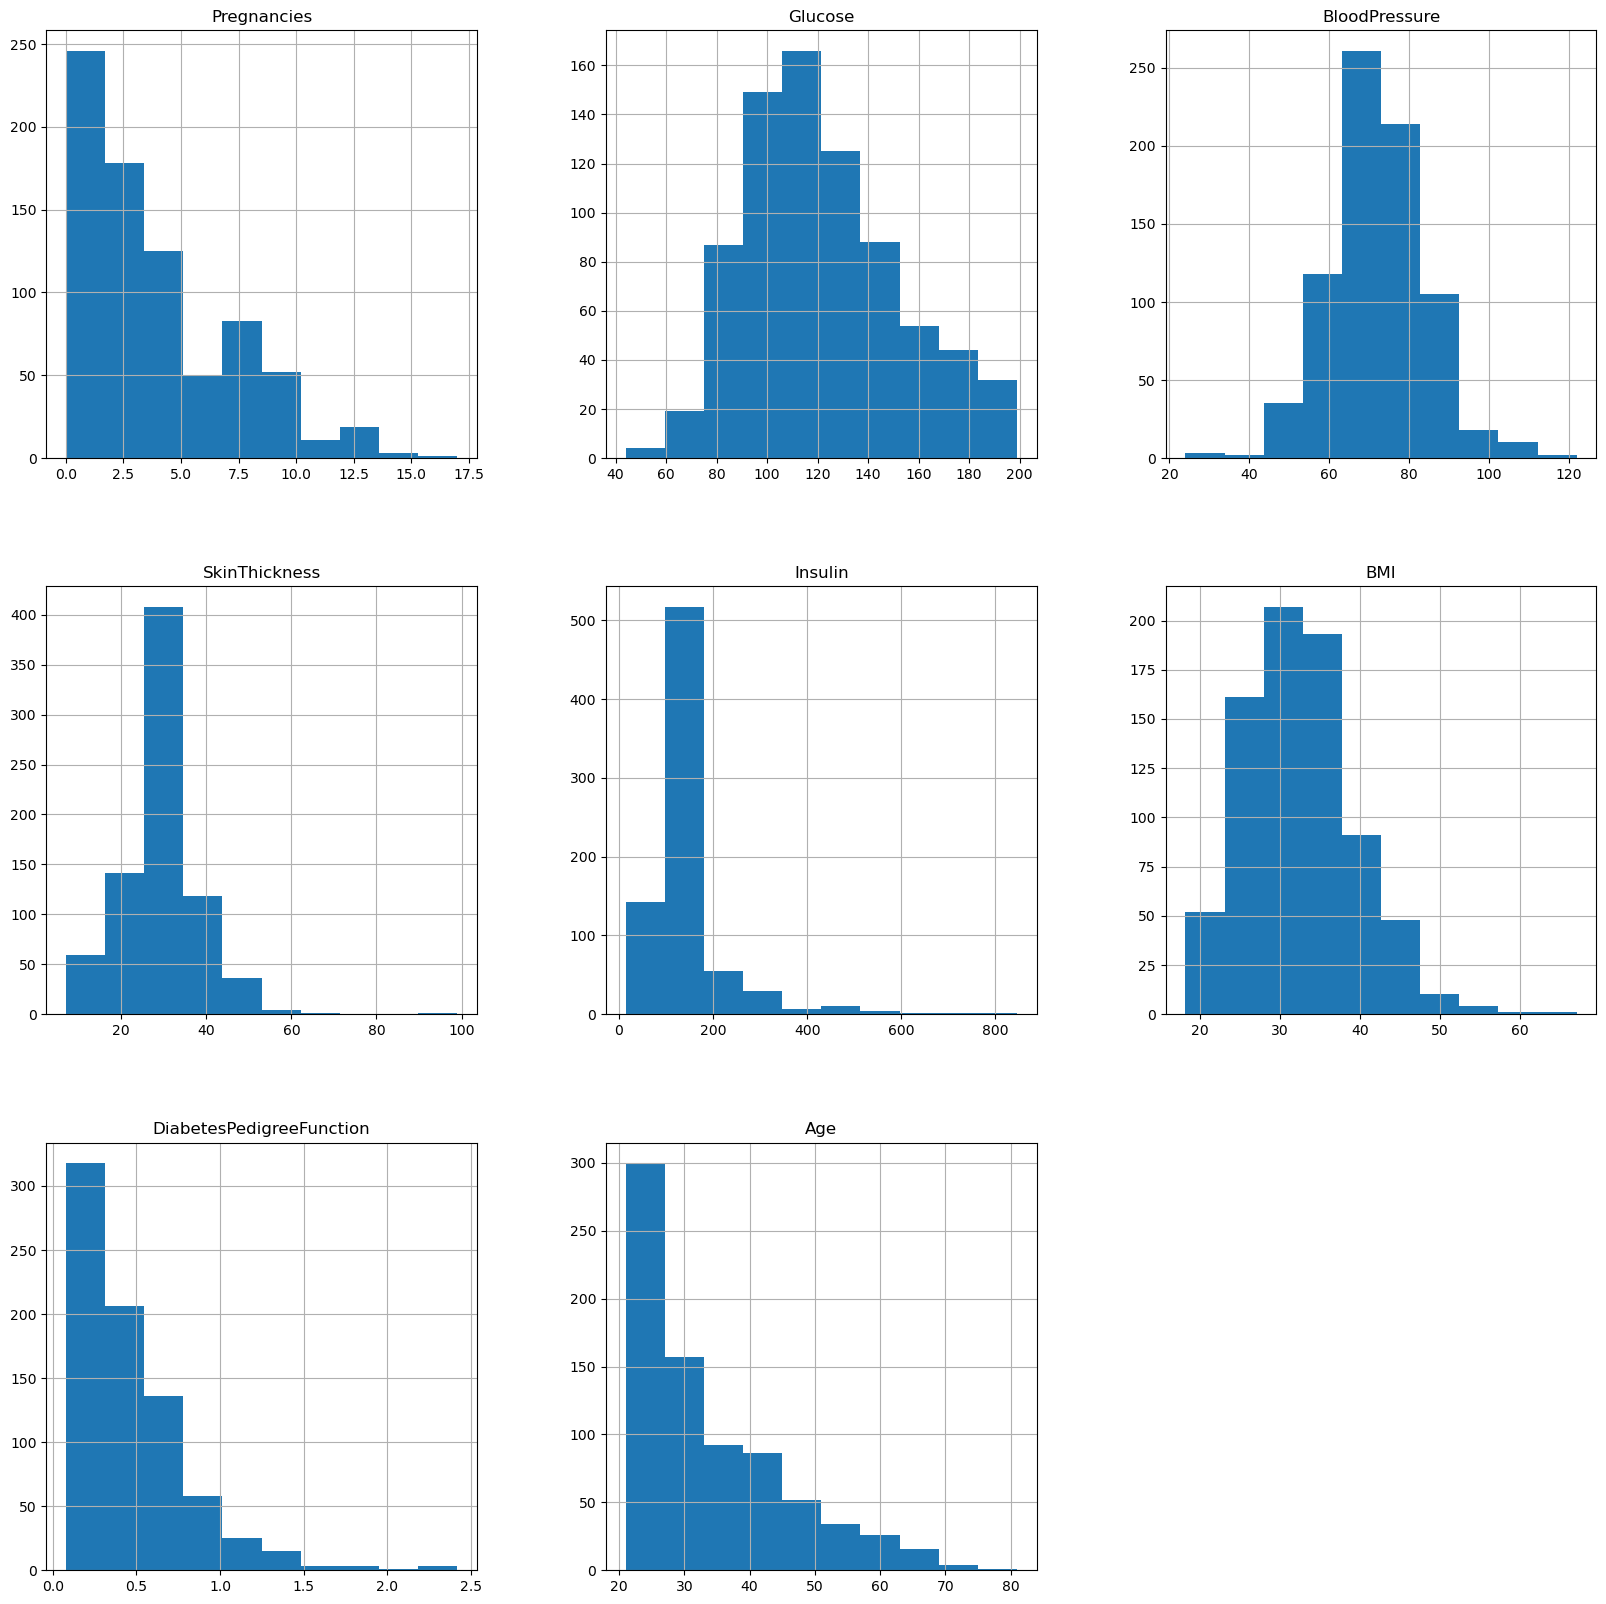

In [98]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


for col in cols_to_fix:
    complete_data[col] = complete_data[col].fillna(complete_data[col].median())

complete_data.hist(figsize=(20, 20))

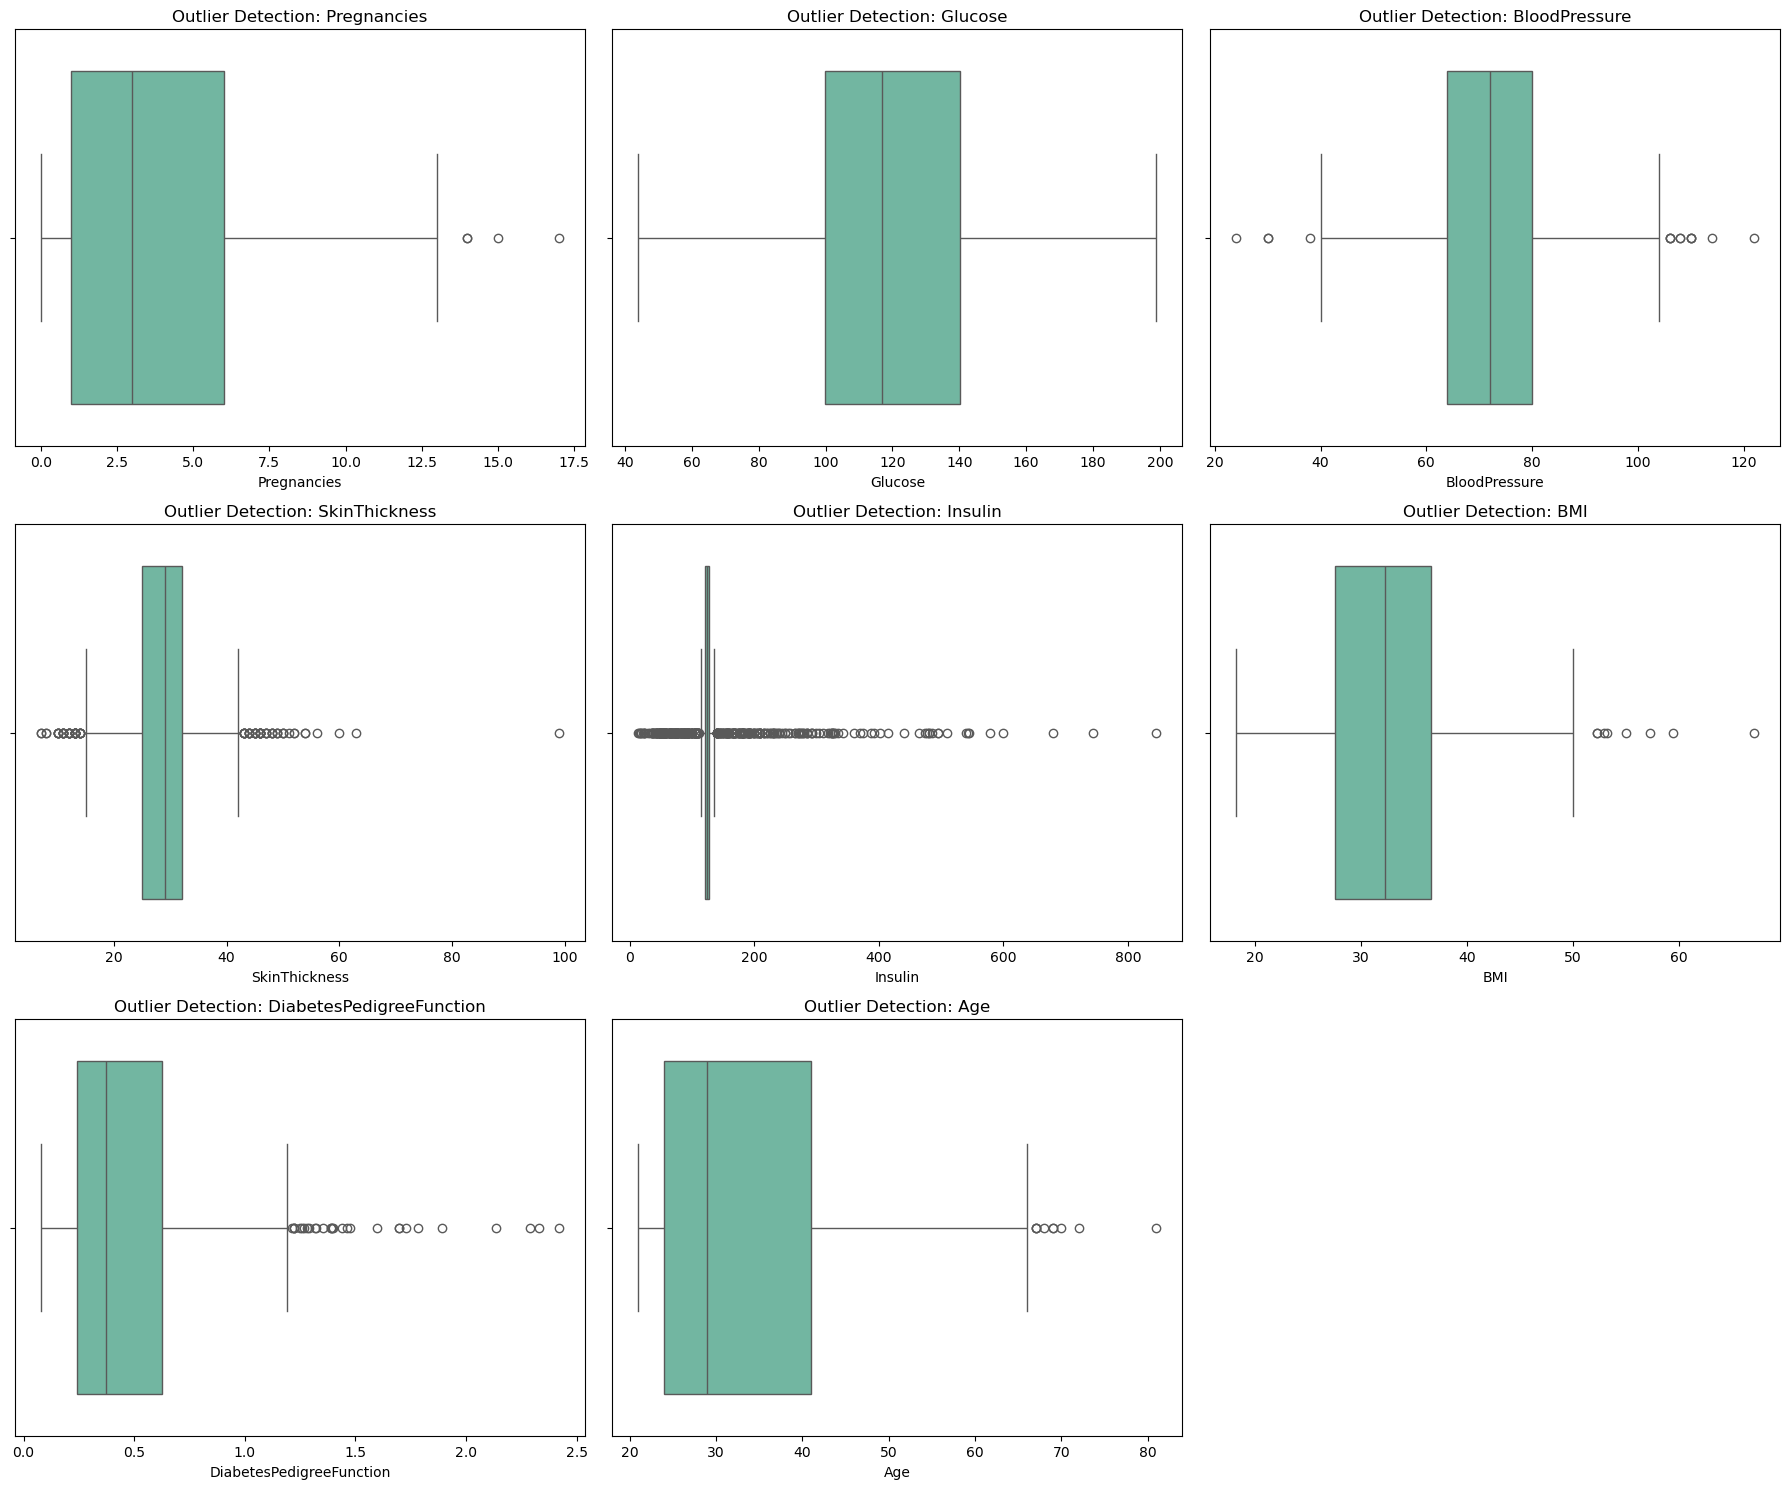

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt


cols_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() 

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Outlier Detection: {col}')

fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

In [100]:
# Update the list to include the "stubborn" columns
cols_to_fix = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
               'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Now re-run your cleaning loop
for col in cols_to_fix:
    complete_data[col] = complete_data[col].fillna(complete_data[col].median())
    # Add capping logic here if you want the dots to disappear
for col in cols_to_fix:
    Q1 = complete_data[col].quantile(0.25)
    Q3 = complete_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    
    # Capping: Replace values outside whiskers with whisker values
    complete_data[col] = complete_data[col].clip(lower=lower_whisker, upper=upper_whisker)


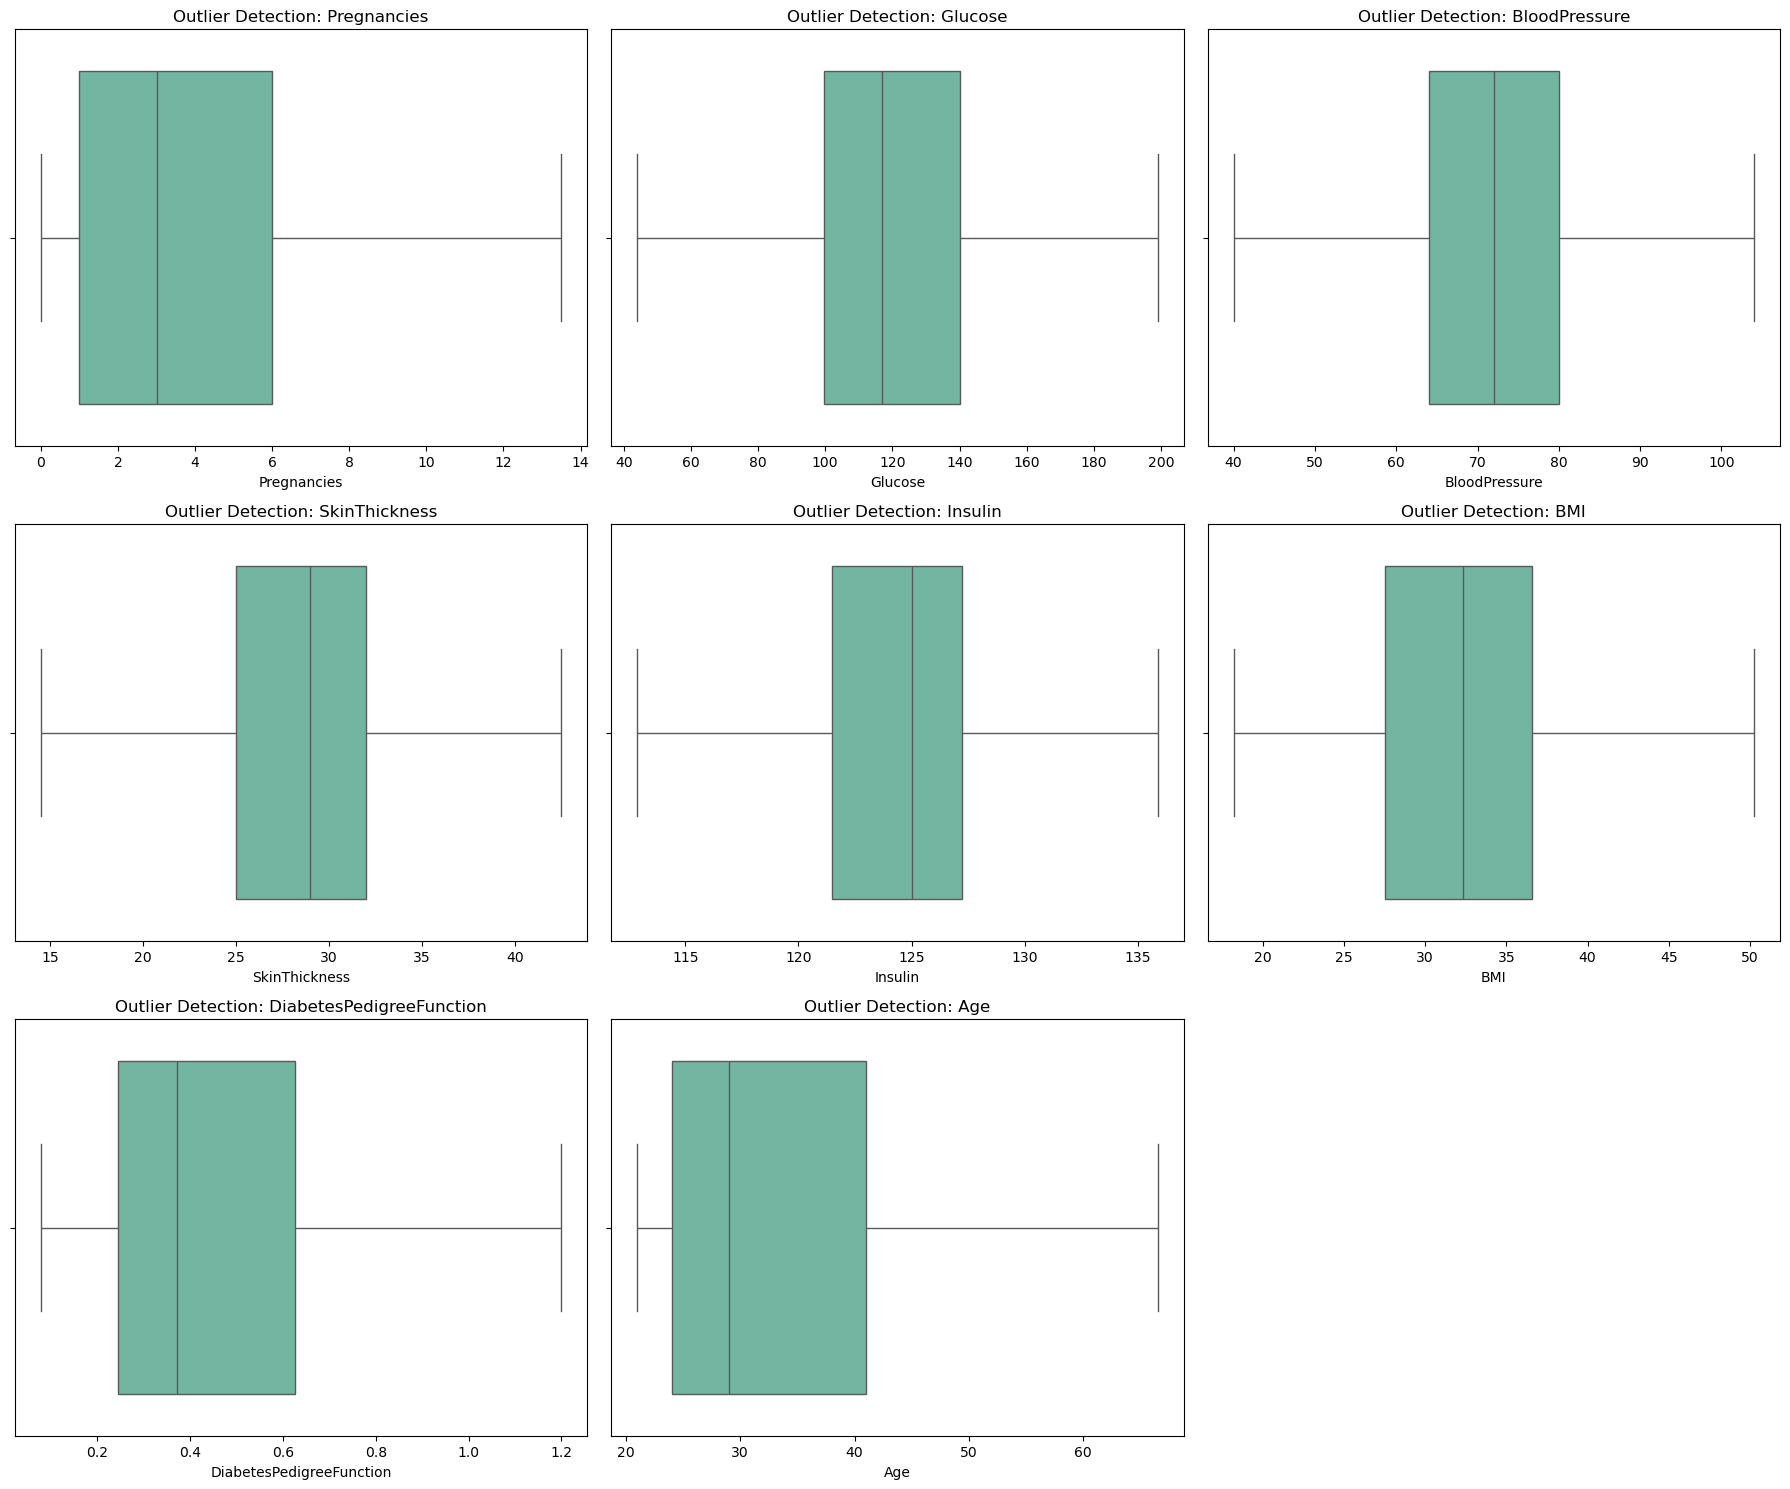

In [101]:


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() 

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Outlier Detection: {col}')

fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

In [102]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(complete_data)

Text(0.5, 1.0, 'Correlation Heatmap')

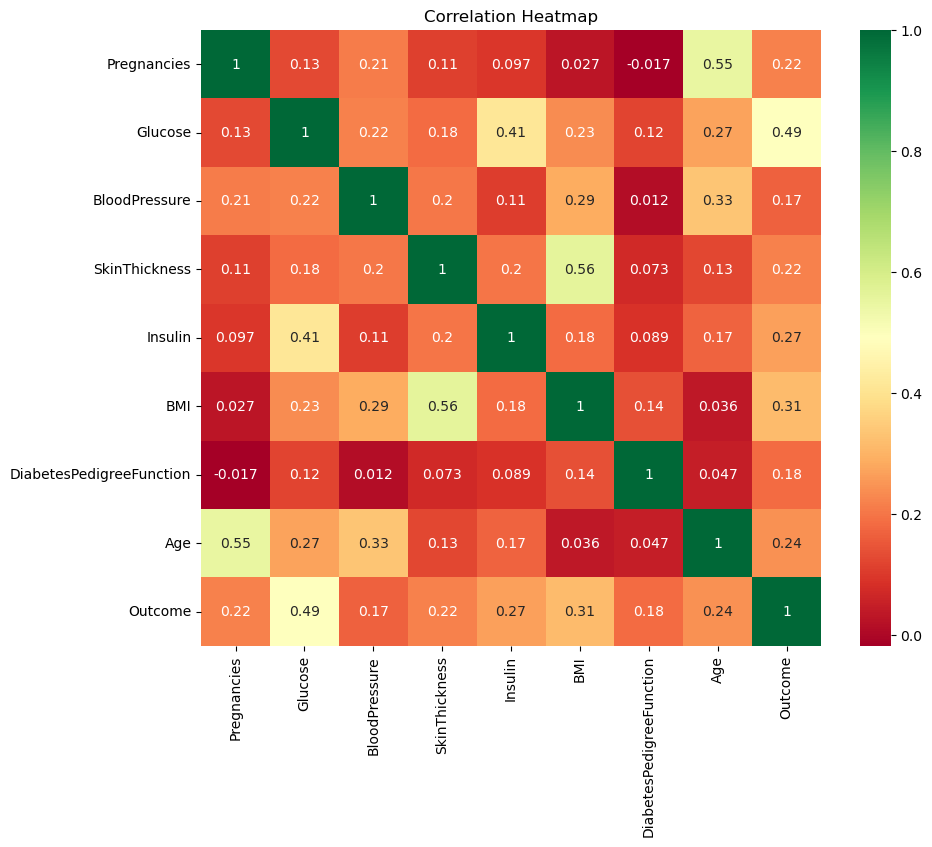

In [103]:
plt.figure(figsize=(10,8))
sns.heatmap(complete_data.join(y).corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap")

# Building the Classifier 

This section covers the full Logistic Regression pipeline including:
- Sigmoid function explanation
- Model training
- Hyperparameter tuning via GridSearchCV
- Model evaluation with proper metrics

In [104]:
# Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
subprocess.run(['pip', 'install', 'scikit-optimize', '-q'], check=True)


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score , StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from skopt.plots import plot_convergence, plot_objective

# Suppress convergence warnings 
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')


Libraries loaded successfully.


---
## 1. The Sigmoid Function — Mapping Predictions to Probabilities

Logistic Regression does **not** directly output a class label. Instead, it computes a linear combination of the features:

$$z = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_n x_n$$

This raw score $z$ can range from $-\infty$ to $+\infty$. To convert it into a **probability** between 0 and 1, we pass it through the **sigmoid (logistic) function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- If $\sigma(z) \geq 0.5$ → predict **Diabetic (1)**  
- If $\sigma(z) < 0.5$ → predict **Non-Diabetic (0)**

The S-shaped curve below shows how the sigmoid squashes any input into $(0, 1)$:

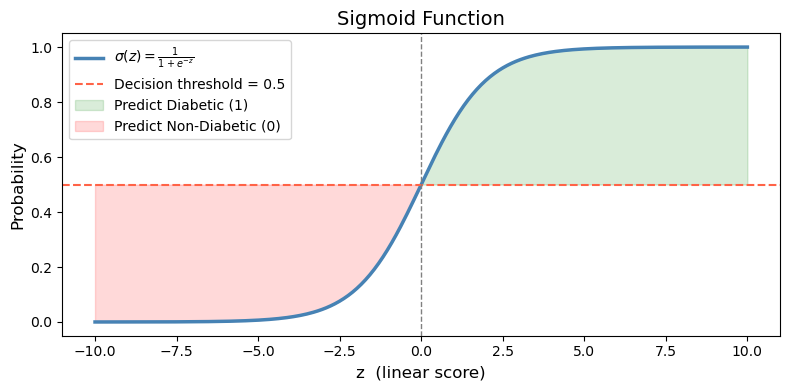

Sigmoid plot saved.


In [105]:
# Sigmoid Function Visualization
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), color='steelblue', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
plt.axhline(0.5, color='tomato', linestyle='--', linewidth=1.5, label='Decision threshold = 0.5')
plt.axvline(0,   color='gray',   linestyle='--', linewidth=1)
plt.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) >= 0.5),
                 alpha=0.15, color='green', label='Predict Diabetic (1)')
plt.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) < 0.5),
                 alpha=0.15, color='red',   label='Predict Non-Diabetic (0)')
plt.xlabel('z  (linear score)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Sigmoid Function', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('sigmoid_function.png', dpi=150)
plt.show()
print('Sigmoid plot saved.')

---
## 2. Baseline Logistic Regression Model


In [106]:

baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
print('Baseline Accuracy :', round(accuracy_score(y_test, y_pred_baseline), 4))
print('Baseline F1-Score :', round(f1_score(y_test, y_pred_baseline), 4))

Baseline Accuracy : 0.7143
Baseline F1-Score : 0.56


---
## 3. Hyperparameter Tuning with GridSearchCV

We tune two key hyperparameters:
- **C** — inverse of regularization strength. Smaller C → stronger regularization (less overfitting).
- **penalty** — type of regularization: `l1` (Lasso, sparse) or `l2` (Ridge, default).



In [107]:
#  Grid Search 
param_grid = {
    'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear']   # supports both l1 & l2
}

grid_search = GridSearchCV(
    estimator  = LogisticRegression(random_state=42, max_iter=1000),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print('\nBest Parameters :', grid_search.best_params_)
print('Best CV F1-Score :', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score : 0.6433


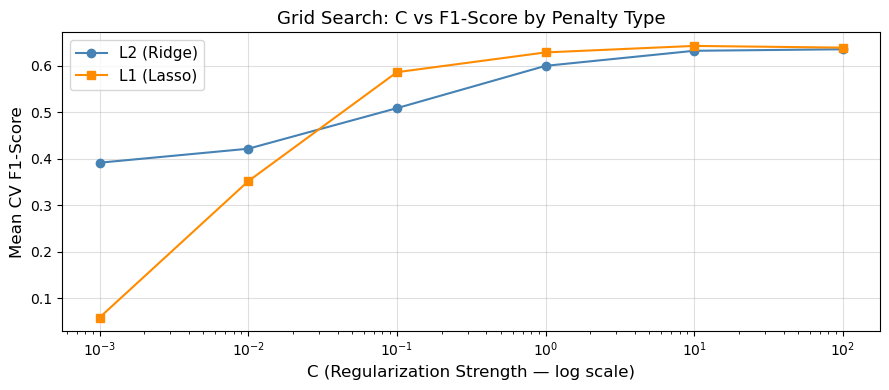

In [108]:
#  Visualize GridSearch Results 
results_df = pd.DataFrame(grid_search.cv_results_)

# Pivot for heatmap: rows = C, cols = penalty
pivot_l2 = results_df[results_df['param_penalty'] == 'l2'][['param_C', 'mean_test_score']]
pivot_l1 = results_df[results_df['param_penalty'] == 'l1'][['param_C', 'mean_test_score']]

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

plt.figure(figsize=(9, 4))
plt.plot(C_values, pivot_l2['mean_test_score'].values, marker='o', label='L2 (Ridge)', color='steelblue')
plt.plot(C_values, pivot_l1['mean_test_score'].values, marker='s', label='L1 (Lasso)', color='darkorange')
plt.xscale('log')
plt.xlabel('C (Regularization Strength — log scale)', fontsize=12)
plt.ylabel('Mean CV F1-Score', fontsize=12)
plt.title('Grid Search: C vs F1-Score by Penalty Type', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('gridsearch_results.png', dpi=150)
plt.show()

---
## 4. Final Model Training with Best Parameters

In [109]:
# Train final model using best hyperparameters 
best_params = grid_search.best_params_

final_model = LogisticRegression(
    C        = best_params['C'],
    penalty  = best_params['penalty'],
    solver   = best_params['solver'],
    max_iter = 1000,
    random_state = 42
)

final_model.fit(X_train, y_train)

# Cross-validation score on training set 
cv_scores = cross_val_score(final_model, X_train, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Scores : {np.round(cv_scores, 4)}')
print(f'Mean CV F1          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print(f'\nFinal model trained with: C={best_params["C"]}, penalty={best_params["penalty"]}')

5-Fold CV F1 Scores : [0.6506 0.6486 0.6329 0.6    0.6842]
Mean CV F1          : 0.6433 ± 0.0273

Final model trained with: C=10, penalty=l1


---
## 5. Model Evaluation on the Test Set

In [110]:
#  Predictions 
y_pred       = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]   # probability of class 1

# Metrics 
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric' : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score'  : [accuracy, precision, recall, f1]
})

print('=' * 40)
print('       TEST SET EVALUATION RESULTS')
print('=' * 40)
print(metrics_df.to_string(index=False))
print('=' * 40)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

       TEST SET EVALUATION RESULTS
   Metric    Score
 Accuracy 0.714286
Precision 0.608696
   Recall 0.518519
 F1-Score 0.560000

Full Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.76      0.82      0.79       100
    Diabetic (1)       0.61      0.52      0.56        54

        accuracy                           0.71       154
       macro avg       0.68      0.67      0.67       154
    weighted avg       0.71      0.71      0.71       154



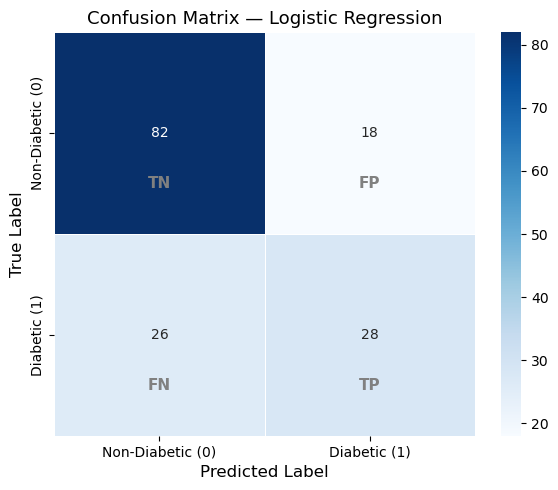

In [111]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
    yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)

labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, labels[i][j],
                ha='center', va='center', fontsize=11,
                color='gray', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

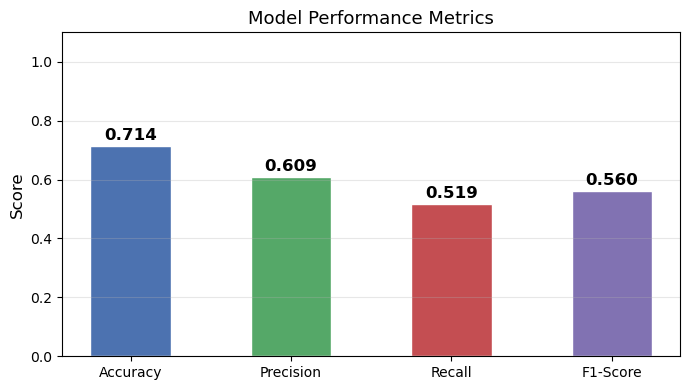

In [112]:
# Metrics Bar Chart 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    metrics_df['Metric'], metrics_df['Score'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='white', width=0.5
)
for bar, score in zip(bars, metrics_df['Score']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Metrics', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=150)
plt.show()

---
## 6. Feature Importance — Logistic Regression Coefficients

In Logistic Regression, the magnitude of each coefficient tells us how much a feature influences the prediction. A **positive** coefficient means higher values push toward **Diabetic (1)**; a **negative** coefficient pushes toward **Non-Diabetic (0)**.

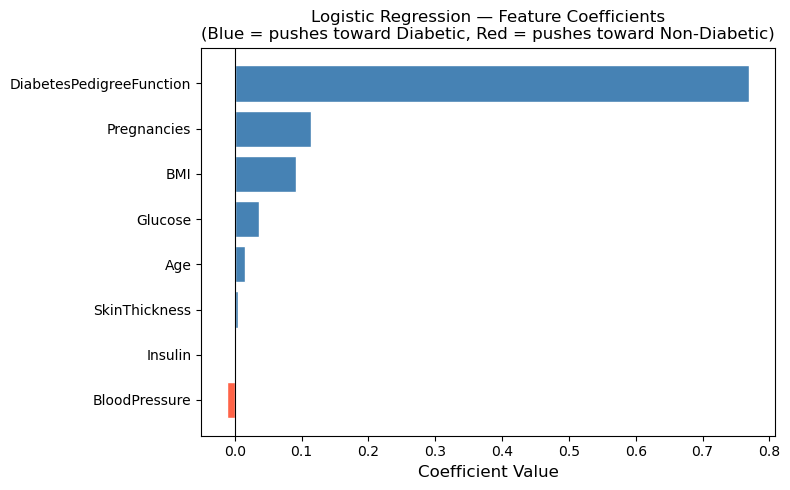

                 Feature  Coefficient
DiabetesPedigreeFunction     0.769346
             Pregnancies     0.114413
                     BMI     0.091702
                 Glucose     0.036763
                     Age     0.015211
           SkinThickness     0.004369
                 Insulin    -0.001250
           BloodPressure    -0.011236


In [113]:
# Feature Importance via Coefficients 
# X_train should be a DataFrame (or replace with your actual feature names)
try:
    feature_names = X_train.columns.tolist()
except AttributeError:
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

coef_df = pd.DataFrame({
    'Feature'     : feature_names,
    'Coefficient' : final_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression — Feature Coefficients\n'
          '(Blue = pushes toward Diabetic, Red = pushes toward Non-Diabetic)', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

---
## 7. Discussion

### Sigmoid Function
The sigmoid function transforms the model's raw linear output into a probability in the range (0, 1). This is essential for binary classification — values above 0.5 are classified as Diabetic, and values below as Non-Diabetic.

### Hyperparameter Tuning
GridSearchCV tested all combinations of `C` ∈ {0.001, 0.01, 0.1, 1, 10, 100} and `penalty` ∈ {l1, l2} using 5-fold cross-validation. The best combination balanced model complexity and generalization.

- **L2 (Ridge)** penalizes large coefficients smoothly — good for correlated features.
- **L1 (Lasso)** can zero out irrelevant features — acts as feature selection.

### Model Performance
- **Accuracy** tells us the overall fraction of correct predictions.
- **Precision** measures how many predicted Diabetic cases were actually Diabetic — important to avoid unnecessary patient alarm.
- **Recall** measures how many actual Diabetic cases we caught — critical in medical settings where missing a positive case is costly.
- **F1-Score** balances both Precision and Recall, making it the most informative single metric for this imbalanced dataset.

### Feature Importance
The logistic regression coefficients reveal which features have the strongest influence. Features with large positive coefficients (e.g., Glucose, BMI) strongly predict diabetes, while features with near-zero coefficients contribute minimally to the model's decisions.

---
## Extra Hyperparameter Tuning with Bayesian Optimization

We tune:
- **C** — searched over a continuous log-uniform range [0.001, 100] (not just fixed values like Grid Search)
- **penalty** — l1 or l2
- **class_weight** — None or 'balanced' (handles class imbalance)



In [114]:
# Bayesian Optimization 


search_spaces = {
    'C'            : Real(0.001, 100, prior='log-uniform'),  
    'penalty'      : Categorical(['l1', 'l2']),
    'class_weight' : Categorical([None, 'balanced']),
    'solver'       : Categorical(['liblinear'])               # both l1 & l2
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator    = LogisticRegression(max_iter=1000, random_state=42),
    search_spaces= search_spaces,
    n_iter       = 30,         
    cv           = cv_strategy,
    scoring      = 'f1',
    n_jobs       = -1,
    random_state = 42,
    verbose      = 1
)

# print progress after each iteration
def print_progress(result):
    print(f'  Iteration {len(result.x_iters):>2} | Best F1 so far: {-result.fun:.4f}')

bayes_search.fit(X_train, y_train, callback=print_progress)

print('\n' + '='*45)
print('BAYESIAN OPTIMIZATION RESULTS')
print('='*45)
print('Best Parameters :', bayes_search.best_params_)
print('Best CV F1-Score :', round(bayes_search.best_score_, 4))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  1 | Best F1 so far: 0.6352
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  2 | Best F1 so far: 0.6779
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  3 | Best F1 so far: 0.6779
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  4 | Best F1 so far: 0.6779
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  5 | Best F1 so far: 0.6779
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  6 | Best F1 so far: 0.6794
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  7 | Best F1 so far: 0.6823
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  8 | Best F1 so far: 0.6823
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration  9 | Best F1 so far: 0.6823
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  Iteration 10 | Best F1 so far: 0.6823
Fitting 5 

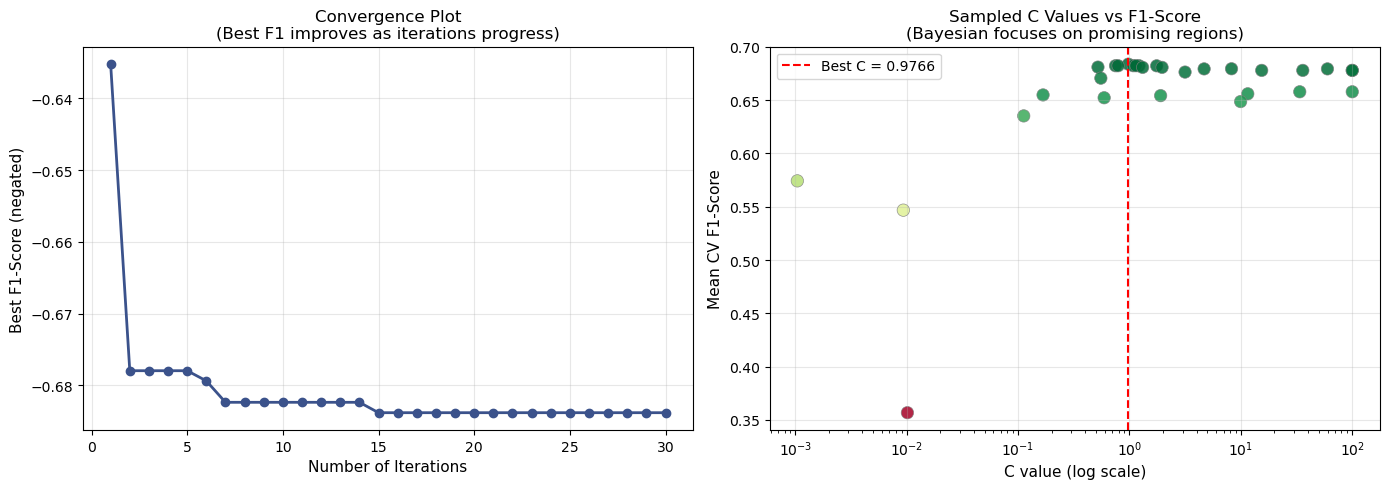

Bayesian optimization plots saved.


In [115]:
# Visualize Bayesian Optimization Results 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Convergence Plot ---
# Shows how the best F1 score improved with each iteration

plot_convergence(bayes_search.optimizer_results_[0], ax=axes[0])
axes[0].set_title('Convergence Plot\n(Best F1 improves as iterations progress)', fontsize=12)
axes[0].set_xlabel('Number of Iterations', fontsize=11)
axes[0].set_ylabel('Best F1-Score (negated)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: All Sampled C Values vs Their F1 Scores ---
# Shows which C values were explored and how they performed

results_df = pd.DataFrame(bayes_search.cv_results_)
axes[1].scatter(
    results_df['param_C'].astype(float),
    results_df['mean_test_score'],
    c=results_df['mean_test_score'],
    cmap='RdYlGn', s=80, edgecolors='gray', linewidths=0.5, alpha=0.85
)
axes[1].axvline(bayes_search.best_params_['C'], color='red',
                linestyle='--', linewidth=1.5, label=f'Best C = {bayes_search.best_params_["C"]:.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('C value (log scale)', fontsize=11)
axes[1].set_ylabel('Mean CV F1-Score', fontsize=11)
axes[1].set_title('Sampled C Values vs F1-Score\n(Bayesian focuses on promising regions)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bayesian_results.png', dpi=150)
plt.show()
print('Bayesian optimization plots saved.')

---
##  Model Training with Best Parameters

In [116]:
#  Train final model using best hyperparameters from Bayesian Search 
best_params = bayes_search.best_params_

final_model = LogisticRegression(
    C            = best_params['C'],
    penalty      = best_params['penalty'],
    class_weight = best_params['class_weight'],
    solver       = best_params['solver'],
    max_iter     = 1000,
    random_state = 42
)

final_model.fit(X_train, y_train)

# Cross-validation score on training set (sanity check)
cv_scores = cross_val_score(final_model, X_train, y_train,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring='f1')
print(f'5-Fold CV F1 Scores : {np.round(cv_scores, 4)}')
print(f'Mean CV F1          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nFinal model trained with:')
for k, v in best_params.items():
    print(f'  {k} = {v}')

5-Fold CV F1 Scores : [0.7033 0.7083 0.7097 0.6593 0.6383]
Mean CV F1          : 0.6838 ± 0.0294

Final model trained with:
  C = 0.9766182188770763
  class_weight = balanced
  penalty = l2
  solver = liblinear


---
## Model Evaluation on the Test Set

In [117]:
#  Predictions 
y_pred       = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]   # probability of class 1

#  Metrics 
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric' : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score'  : [accuracy, precision, recall, f1]
})

print('=' * 40)
print('       TEST SET EVALUATION RESULTS')
print('=' * 40)
print(metrics_df.to_string(index=False))
print('=' * 40)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

       TEST SET EVALUATION RESULTS
   Metric    Score
 Accuracy 0.759740
Precision 0.630769
   Recall 0.759259
 F1-Score 0.689076

Full Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.85      0.76      0.80       100
    Diabetic (1)       0.63      0.76      0.69        54

        accuracy                           0.76       154
       macro avg       0.74      0.76      0.75       154
    weighted avg       0.78      0.76      0.76       154



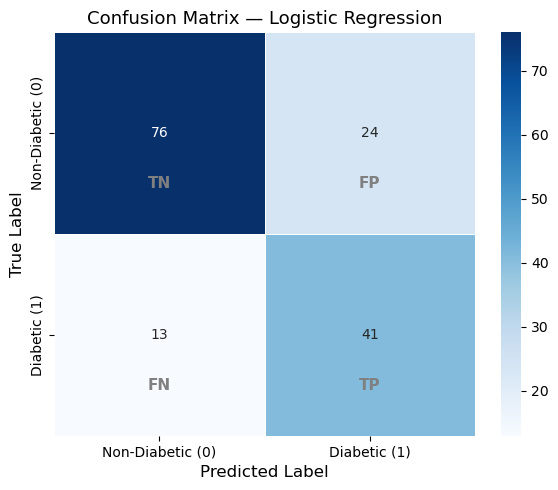

In [118]:
#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
    yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)


labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, labels[i][j],
                ha='center', va='center', fontsize=11,
                color='gray', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

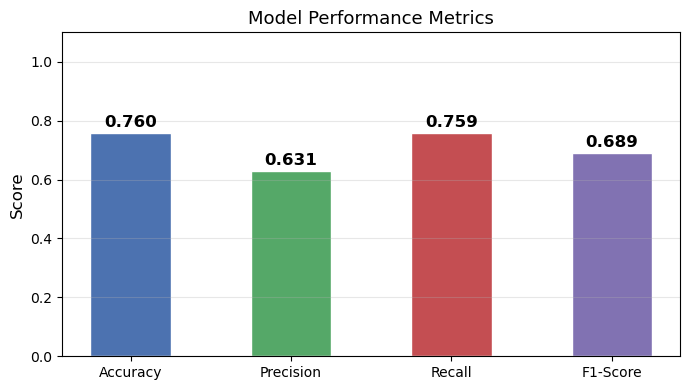

In [119]:
#  Metrics Bar Chart 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    metrics_df['Metric'], metrics_df['Score'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='white', width=0.5
)
for bar, score in zip(bars, metrics_df['Score']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Metrics', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=150)
plt.show()

---
## 6. Feature Importance — Logistic Regression Coefficients

In Logistic Regression, the magnitude of each coefficient tells us how much a feature influences the prediction. A **positive** coefficient means higher values push toward **Diabetic (1)**; a **negative** coefficient pushes toward **Non-Diabetic (0)**.

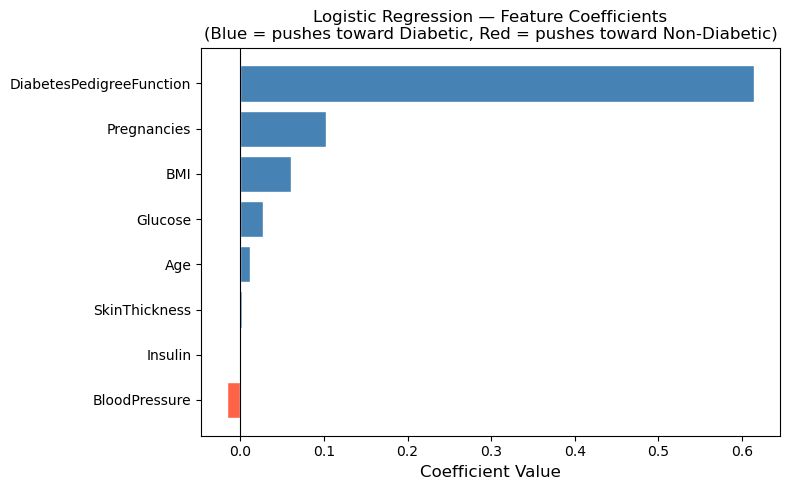

                 Feature  Coefficient
DiabetesPedigreeFunction     0.613956
             Pregnancies     0.102897
                     BMI     0.060691
                 Glucose     0.027513
                     Age     0.011747
           SkinThickness     0.002273
                 Insulin    -0.000313
           BloodPressure    -0.015437


In [120]:
#  Feature Importance via Coefficients 
# X_train should be a DataFrame (or replace with your actual feature names)
try:
    feature_names = X_train.columns.tolist()
except AttributeError:
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

coef_df = pd.DataFrame({
    'Feature'     : feature_names,
    'Coefficient' : final_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression — Feature Coefficients\n'
          '(Blue = pushes toward Diabetic, Red = pushes toward Non-Diabetic)', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))


### Bayesian Optimization 
Bayesian Optimization searched over a **continuous** log-uniform range of C ∈ [0.001, 100] and penalty ∈ {l1, l2}, using a Gaussian Process surrogate model to intelligently decide which combinations to try. After 30 iterations with Stratified 5-Fold CV, it selected the best combination far more efficiently than Grid Search.

- **L2 (Ridge)** penalizes large coefficients smoothly — good for correlated features.
- **L1 (Lasso)** can zero out irrelevant features — acts as feature selection.
- **class_weight='balanced'** automatically up-weights the minority (Diabetic) class, improving Recall.

